# Modules

In [1]:
from dateutil import tz

import json
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns

from longitudinal_arm_swing.constants import *

# Constants

In [9]:
from_tz = tz.gettz('UTC')
to_tz = tz.gettz('Europe/Amsterdam')
round_minutes = 5

save_plots = True

# Load

In [10]:
d_stats = {
    'gait': {},
    'arm_swing': {}
}

for week_nr in [2]:
    with open(os.path.join(r'C:\Users\\z665206\Documents\PhD\data\longitudinal\stats', f'gait_stats_week{week_nr}.json'), 'r') as f:
        d_stats['gait'][str(week_nr)] = json.load(f)
    with open(os.path.join(r'C:\Users\\z665206\Documents\PhD\data\longitudinal\stats', f'arm_activity_stats_week{week_nr}.json'), 'r') as f:
        d_stats['arm_swing'][str(week_nr)] = json.load(f)


# Process

C:\Users\z665206\AppData\Local\Temp\ipykernel_11316\606636239.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{int(x*100)}%' for x in ax.get_yticks()], size=PLOT_TICKSIZE)


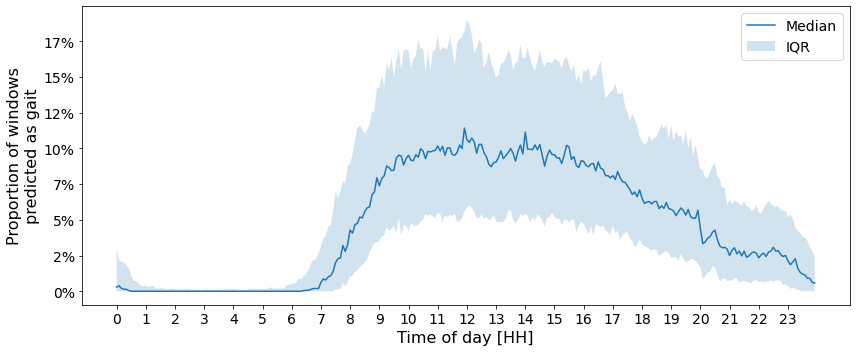

In [11]:
scalers_rename = {
    'pdh': 'PD@Home scaler',
    'subset': 'PPP scaler',
}

scalers = ['pdh']
week_nr = '2'
activity = 'gait'
      
fig, ax = plt.subplots(figsize=(12,5))

for scaler in scalers:
    for subject in d_stats[activity][week_nr].keys():
        if scaler not in d_stats[activity][week_nr][subject].keys():
            continue
        for hour in d_stats[activity][week_nr][subject][scaler]['hour_minutes'].keys():
            for minute in d_stats[activity][week_nr][subject][scaler]['hour_minutes'][hour].keys():
                if 'pred_pos_s' not in d_stats[activity][week_nr][subject][scaler]['hour_minutes'][hour][minute].keys():
                    d_stats[activity][week_nr][subject][scaler]['hour_minutes'][hour][minute]['pred_pos_s'] = 0
                if 'pred_neg_s' not in d_stats[activity][week_nr][subject][scaler]['hour_minutes'][hour][minute].keys():
                    d_stats[activity][week_nr][subject][scaler]['hour_minutes'][hour][minute]['pred_neg_s'] = 0

    d_prop_detailed = {}
    for hour in range(24):
        for minute in range(0, 60, 5):
            d_prop_detailed[str(hour+minute/60)] = {}
            if scaler not in d_stats[activity][week_nr][subject].keys():
                continue
            minute_stats = [d_stats[activity][week_nr][x][scaler]['hour_minutes'][str(hour)][str(minute)][f'pred_pos_s'] / (d_stats[activity][week_nr][x][scaler]['hour_minutes'][str(hour)][str(minute)][f'pred_pos_s'] + d_stats[activity][week_nr][x][scaler]['hour_minutes'][str(hour)][str(minute)]['pred_neg_s']) for x in d_stats[activity][week_nr].keys() if str(hour) in d_stats[activity][week_nr][x][scaler]['hour_minutes'].keys() and str(minute) in d_stats[activity][week_nr][x][scaler]['hour_minutes'][str(hour)].keys() and d_stats[activity][week_nr][x][scaler]['hour_minutes'][str(hour)][str(minute)][f'pred_pos_s'] + d_stats[activity][week_nr][x][scaler]['hour_minutes'][str(hour)][str(minute)]['pred_neg_s'] > 0]
            if len(minute_stats) > 0:
                d_prop_detailed[str(hour+minute/60)]['gait'] = {
                    'q1': np.quantile([d_stats[activity][week_nr][x][scaler]['hour_minutes'][str(hour)][str(minute)][f'pred_pos_s'] / (d_stats[activity][week_nr][x][scaler]['hour_minutes'][str(hour)][str(minute)][f'pred_pos_s'] + d_stats[activity][week_nr][x][scaler]['hour_minutes'][str(hour)][str(minute)]['pred_neg_s']) for x in d_stats[activity][week_nr].keys() if str(hour) in d_stats[activity][week_nr][x][scaler]['hour_minutes'].keys() and str(minute) in d_stats[activity][week_nr][x][scaler]['hour_minutes'][str(hour)].keys() and d_stats[activity][week_nr][x][scaler]['hour_minutes'][str(hour)][str(minute)][f'pred_pos_s'] + d_stats[activity][week_nr][x][scaler]['hour_minutes'][str(hour)][str(minute)]['pred_neg_s'] > 0], 0.25),
                    'q2': np.quantile([d_stats[activity][week_nr][x][scaler]['hour_minutes'][str(hour)][str(minute)][f'pred_pos_s'] / (d_stats[activity][week_nr][x][scaler]['hour_minutes'][str(hour)][str(minute)][f'pred_pos_s'] + d_stats[activity][week_nr][x][scaler]['hour_minutes'][str(hour)][str(minute)]['pred_neg_s']) for x in d_stats[activity][week_nr].keys() if str(hour) in d_stats[activity][week_nr][x][scaler]['hour_minutes'].keys() and str(minute) in d_stats[activity][week_nr][x][scaler]['hour_minutes'][str(hour)].keys() and d_stats[activity][week_nr][x][scaler]['hour_minutes'][str(hour)][str(minute)][f'pred_pos_s'] + d_stats[activity][week_nr][x][scaler]['hour_minutes'][str(hour)][str(minute)]['pred_neg_s'] > 0], 0.5),
                    'q3': np.quantile([d_stats[activity][week_nr][x][scaler]['hour_minutes'][str(hour)][str(minute)][f'pred_pos_s'] / (d_stats[activity][week_nr][x][scaler]['hour_minutes'][str(hour)][str(minute)][f'pred_pos_s'] + d_stats[activity][week_nr][x][scaler]['hour_minutes'][str(hour)][str(minute)]['pred_neg_s']) for x in d_stats[activity][week_nr].keys() if str(hour) in d_stats[activity][week_nr][x][scaler]['hour_minutes'].keys() and str(minute) in d_stats[activity][week_nr][x][scaler]['hour_minutes'][str(hour)].keys() and d_stats[activity][week_nr][x][scaler]['hour_minutes'][str(hour)][str(minute)][f'pred_pos_s'] + d_stats[activity][week_nr][x][scaler]['hour_minutes'][str(hour)][str(minute)]['pred_neg_s'] > 0], 0.75)
                }

    if len(scalers) > 1:
        label_line = f'Median ({scalers_rename[scaler]})'
        label_iqr = f'IQR ({scalers_rename[scaler]})'
    else:
        label_line = 'Median'
        label_iqr = 'IQR'

    sns.lineplot(x=d_prop_detailed.keys(), y=[d_prop_detailed[x]['gait']['q2'] for x in d_prop_detailed if 'gait' in d_prop_detailed[x]], ax=ax, label=label_line)
    ax.fill_between(x=d_prop_detailed.keys(), y1=[d_prop_detailed[x]['gait']['q1'] for x in d_prop_detailed if 'gait' in d_prop_detailed[x]], y2=[d_prop_detailed[x]['gait']['q3'] for x in d_prop_detailed if 'gait' in d_prop_detailed[x]], alpha=0.2, label=label_iqr)

    start, end = ax.get_xlim()
    ax.set_xticks(np.arange(0, 24*12, 12), [f'{x//12}' for x in range(0, 24*12, 12)])
    ax.set_yticklabels([f'{int(x*100)}%' for x in ax.get_yticks()], size=PLOT_TICKSIZE)
    # ax.set_title(f'Daily distribution of predicted gait', size=PLOT_TITLESIZE)
    ax.set_ylabel(f'Proportion of windows\npredicted as gait', size=PLOT_LABELSIZE)
    ax.set_xlabel('Time of day [HH]', size=PLOT_LABELSIZE)
    ax.legend(fontsize=PLOT_LEGEND_FONTSIZE)
    ax.tick_params(axis='both', labelsize=PLOT_TICKSIZE)

fig.tight_layout()

plt.show()

if save_plots:
    fig.savefig(os.path.join(PATH_FIGURES, 'sr_daily_dist_gait.png'), dpi=600)
    fig.savefig(os.path.join(PATH_FIGURES, 'vectors', 'sr_daily_dist_gait.pdf'), dpi=600)